In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Esercizio 10.1-2

Per questo esercizio ho implementato un **algoritmo genetico** per risolvere il problema del commesso viaggiatore (TSP), utilizzando **MPI** per parallelizzare l'evoluzione della popolazione. L'obiettivo è trovare il percorso chiuso di lunghezza minima che permetta di visitare tutte le città una sola volta, tornando infine alla città di partenza.

Ho suddiviso il programma in tre componenti principali: la gestione delle città, la rappresentazione dei singoli percorsi (`Path`) e la gestione della popolazione (`Population`). Nel `main` viene invece gestita l'evoluzione delle popolazioni e la comunicazione tra i diversi processi MPI.

### 1. Inizializzazione

All'inizio del programma inizializzo MPI e ricavo il numero totale di processi e il `rank` del processo corrente (nel mio caso ho scelto 8 core). Ogni processo possiede quindi una propria popolazione indipendente e può farla evolvere in parallelo rispetto agli altri processi.

Il generatore di numeri casuali viene inizializzato utilizzando i valori contenuti nei file `Primes` e `seed.in`. Le città vengono invece lette dal file `cap_prova_ita.dat` nell'esercizio 10.2 e gli ho generati sul quadrato nell'esercizio 10.1.

Ho scelto una popolazione costituita da

$$
N_{\mathrm{pop}}=50
$$

individui e ho fatto evolvere ogni popolazione per

$$
N_{\mathrm{gen}}=100000
$$

generazioni. La migrazione tra i diversi processi viene effettuata ogni

$$
N_{\mathrm{migr}}=50
$$

generazioni.

### 2. Generazione della popolazione iniziale

La classe `Population` costruisce inizialmente una popolazione di percorsi validi. Per ogni individuo parto dal percorso ordinato

$$
0,1,2,\ldots,N_{\mathrm{city}}-1
$$

e successivamente applico 100 scambi casuali tra città diverse dalla città 0.

La città 0 viene mantenuta fissa come prima città del percorso, in modo da avere una convenzione comune per tutti i percorsi e garantire che il percorso possa essere interpretato come un percorso chiuso che parte e termina dalla stessa città.

### 3. Fitness e ordinamento della popolazione

La qualità di un individuo è determinata dalla lunghezza del percorso. Per ogni percorso calcolo

$$
L=\sum_{i=0}^{N_{\mathrm{city}}-2}
d(c_i,c_{i+1})+
d(c_{N_{\mathrm{city}}-1},c_0),
$$

dove $d(c_i,c_j)$ è la distanza tra due città consecutive.

Poiché vogliamo minimizzare la lunghezza, ordino la popolazione in modo crescente rispetto alla fitness, cioè dalla configurazione migliore a quella peggiore. La funzione `best()` restituisce quindi il primo individuo della popolazione, mentre `best_length()` ne restituisce la lunghezza.

### 4. Selezione dei genitori

Per generare la nuova popolazione seleziono due genitori, indicati come `M` e `F`, utilizzando la funzione `select`.

La selezione non è uniforme: l'indice dell'individuo viene ottenuto tramite

$$
i=\left\lfloor N_{\mathrm{pop}}x^p\right\rfloor,
$$

dove $x$ è un numero casuale uniforme tra 0 e 1 e nel programma utilizzo $p=2$.

Poiché $x^2$ tende a produrre valori più piccoli rispetto a $x$, questo metodo favorisce la selezione degli individui che si trovano nelle prime posizioni della popolazione, cioè quelli con fitness migliore.

### 5. Crossover

Una volta selezionati i due genitori, con probabilità $0.7$ applico il crossover. Ho implementato un crossover a partire da una porzione di uno dei due genitori e completando il figlio utilizzando le città presenti nell'altro genitore, mantenendo l'ordine con cui compaiono.

In particolare, viene scelta casualmente una posizione di taglio e viene copiata nel figlio la parte iniziale del primo genitore. Successivamente vengono inserite, nell'ordine in cui compaiono nel secondo genitore, le città che non sono ancora presenti nel figlio.

Questo procedimento permette di ottenere un nuovo percorso senza ripetizioni e quindi di mantenere la validità della configurazione.

Vengono costruiti due figli, scambiando il ruolo dei due genitori, in modo da rendere il crossover simmetrico.

### 6. Mutazioni

Dopo il crossover applico diverse possibili mutazioni, ciascuna con una determinata probabilità. Le mutazioni implementate sono:

* **swap**, con probabilità $0.3$;
* **shift**, con probabilità $0.1$;
* **permutazione di blocchi**, con probabilità $0.1$;
* **inversione di un segmento**, con probabilità $0.1$.

Queste operazioni modificano il percorso mantenendolo comunque valido, permettendo di esplorare nuove configurazioni dello spazio delle soluzioni.

La mutazione `swap` scambia due città del percorso, mentre `shift` effettua uno spostamento ciclico di una parte del percorso. La permutazione di blocchi modifica l'ordine di due porzioni del percorso e l'inversione cambia l'ordine delle città contenute in un segmento.

Prima di inserire i figli nella nuova popolazione verifico inoltre che i percorsi siano validi tramite `check()`. In questo modo controllo che non siano presenti città duplicate o mancanti.

### 7. Elitismo

Nella costruzione della nuova generazione inserisco immediatamente il miglior individuo della generazione precedente:

```cpp
new_pop.push_back(best());
```

In questo modo il miglior percorso non viene perso a causa delle operazioni genetiche successive. Si tratta quindi di una forma di **elitismo**.

I restanti individui della nuova popolazione vengono generati selezionando i genitori e applicando crossover e mutazioni.

### 8. Parallelizzazione tramite MPI

La parte principale dell'esercizio consiste nell'utilizzare MPI per far evolvere contemporaneamente diverse popolazioni.

Ogni processo MPI possiede infatti una popolazione indipendente. In assenza di comunicazione, ogni rank esplorerebbe autonomamente lo spazio delle possibili soluzioni, partendo da una popolazione casuale diversa.

Per evitare che i diversi processi rimangano completamente indipendenti, ho introdotto un meccanismo di **migrazione** degli individui migliori.

Ogni 50 generazioni, dopo aver ordinato la popolazione, ciascun processo prende il proprio individuo migliore e lo invia a un altro processo MPI.

Per evitare che tutti i processi comunichino sempre con lo stesso vicino, il rank 0 costruisce casualmente una permutazione dei rank. Questa permutazione viene poi condivisa con tutti i processi tramite `MPI_Bcast`.

I processi vengono quindi disposti idealmente lungo un anello: ogni processo invia il proprio miglior percorso al processo successivo e riceve contemporaneamente il miglior percorso dal processo precedente.

La comunicazione viene effettuata tramite `MPI_Sendrecv`, che permette di eseguire contemporaneamente l'invio e la ricezione evitando problemi di sincronizzazione.

Una volta ricevuto il percorso migrante, sostituisco con esso il peggior individuo della popolazione tramite

```cpp
pop.replace_worst(migrant);
```

In questo modo il percorso migliore trovato da un processo può entrare nella popolazione di un altro processo, favorendo la condivisione delle soluzioni migliori senza rendere le popolazioni completamente identiche.

### 9. Evoluzione delle popolazioni

L'evoluzione della popolazione principale viene quindi effettuata secondo il seguente schema:

1. ordino la popolazione in base alla fitness;
2. ogni 50 generazioni, se necessario, effettuo la migrazione;
3. genero una nuova popolazione tramite selezione, crossover e mutazioni;
4. salvo la lunghezza del miglior percorso della generazione.

Per ogni rank salvo questi dati nel file

```text
fitness_rankX.dat
```

dove `X` corrisponde al rank del processo MPI.

Questi file permettono di analizzare l'evoluzione della fitness e di confrontare il comportamento delle diverse popolazioni.

### 10. Ricerca del miglior percorso globale

Al termine delle $100000$ generazioni, ogni processo possiede il proprio miglior percorso. Calcolo quindi la lunghezza del miglior individuo di ciascun rank e utilizzo `MPI_Gather` per raccogliere tutte le lunghezze sul processo 0.

Il rank 0 confronta quindi le lunghezze ottenute dai diversi processi e individua il rank che ha trovato il percorso globalmente migliore.

Successivamente, tramite `MPI_Bcast`, comunica a tutti i processi quale rank contiene la soluzione migliore.

Il processo corrispondente invia infine il proprio percorso al rank 0, che salva la lunghezza minima nel file `best_global_length.dat` e le coordinate delle città appartenenti al percorso nel file `best_global_path.dat`.

Alla fine del file aggiungo nuovamente la città iniziale, in modo da rappresentare esplicitamente il ritorno al punto di partenza e poter utilizzare direttamente i dati per visualizzare il percorso chiuso.

### 11. Confronto con il caso senza migrazione

Per verificare l'effetto della migrazione, dopo aver completato l'algoritmo genetico parallelo eseguo una seconda simulazione nella quale ogni rank evolve una nuova popolazione completamente indipendente.

In questo caso non viene effettuata alcuna comunicazione tra i processi: ogni popolazione viene fatta evolvere autonomamente per $100000$ generazioni utilizzando gli stessi operatori di selezione, crossover e mutazione.

I risultati vengono salvati nei file

```text
fitness_solo_rankX.dat
```

e il percorso finale migliore di ciascun rank viene salvato in

```text
best_solo_rankX.dat.
```

Il confronto tra i due casi permette quindi di valutare l'effetto della migrazione. Nel caso con migrazione, infatti, le popolazioni possono condividere periodicamente le soluzioni migliori trovate dai diversi processi, aumentando lo scambio di informazione tra le popolazioni e potenzialmente migliorando la capacità dell'algoritmo di esplorare lo spazio delle configurazioni.

Nel caso senza migrazione, invece, ogni popolazione evolve completamente indipendentemente e l'unica possibilità di ottenere una soluzione migliore deriva dall'esplorazione casuale effettuata dal singolo processo.


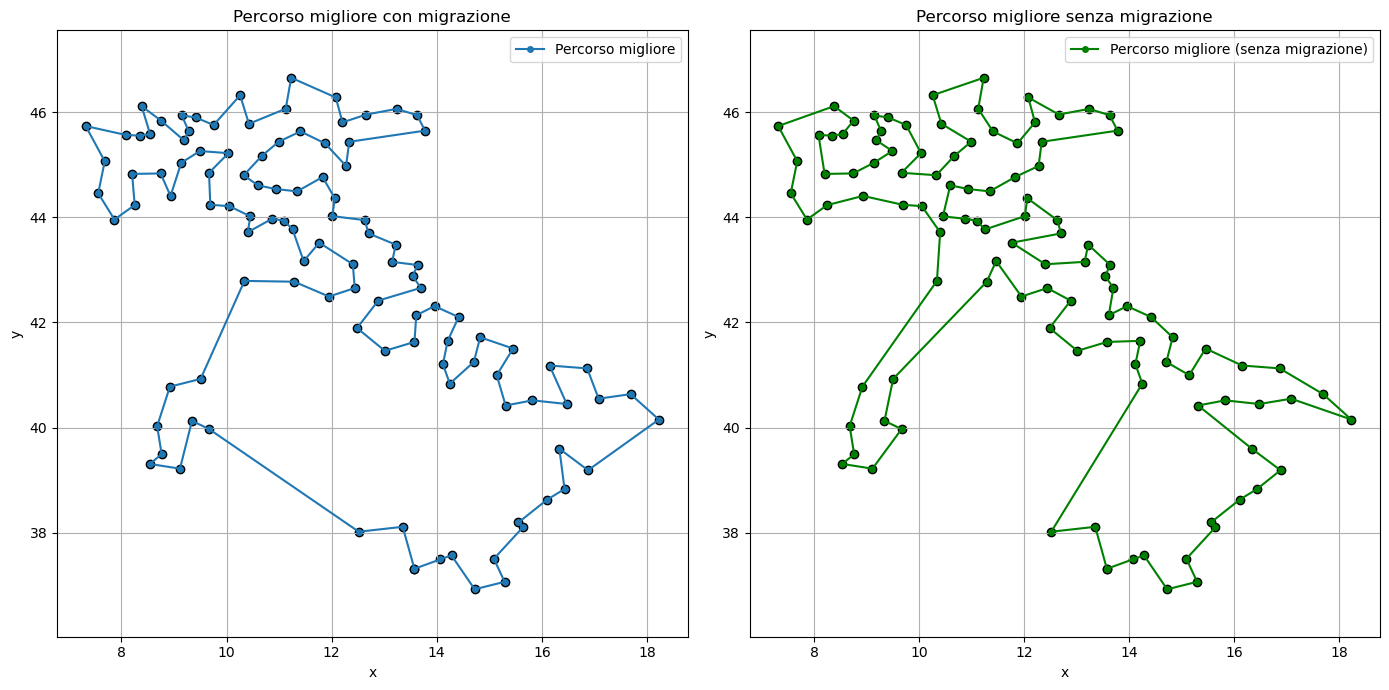

In [8]:
data1 = np.loadtxt("sim_num_es10.2/best_global_path.dat")
ids1 = data1[:,0]
x1 = data1[:,1]
y1 = data1[:,2]

data2 = np.loadtxt("sim_num_es10.2/best_solo_rank0.dat")
ids2 = data2[:,0]
x2 = data2[:,1]
y2 = data2[:,2]

plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.plot(x1, y1, '-o', markersize=4, linewidth=1.5, label="Percorso migliore")
plt.scatter(x1, y1, c='black')

plt.title("Percorso migliore con migrazione")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.subplot(1,2,2)
plt.plot(x2, y2, '-o', markersize=4, linewidth=1.5, label="Percorso migliore (senza migrazione)", c="green")
plt.scatter(x2, y2, c='black')


plt.title("Percorso migliore senza migrazione")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.tight_layout()
plt.show()

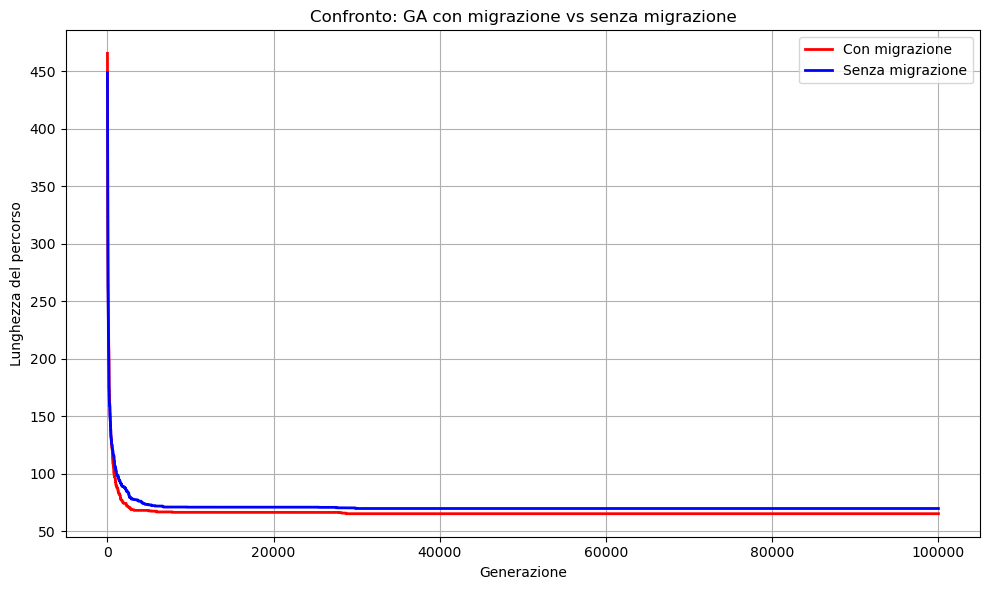

In [9]:
mig = np.loadtxt("sim_num_es10.2/fitness_rank0.dat")
gen_mig = mig[:,0]
cost_mig = mig[:,1]

solo = np.loadtxt("sim_num_es10.2/fitness_solo_rank0.dat")
gen_solo = solo[:,0]
cost_solo = solo[:,1]


plt.figure(figsize=(10,6))

plt.plot(gen_mig, cost_mig, label="Con migrazione", color="red", linewidth=2)
plt.plot(gen_solo, cost_solo, label="Senza migrazione", color="blue", linewidth=2)

plt.xlabel("Generazione")
plt.ylabel("Lunghezza del percorso")
plt.title("Confronto: GA con migrazione vs senza migrazione")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()